#  Bivariate Stats
---
> Bivariate statistics is the branch of statistics that studies **two variables** simultaneously and investigates the relationship, association, or dependence between them.

We have seen examples of it in the week 1 note here we wil analyze them
## Outcomes Of This Week!

- Cross-table // Two way tables
- Row/Column relative freaquency
- Association between two categorical variables
- Association between two numerical variablse
- Association between a numerical and categorical variable

# Tabular summarization of bi-varaite data

## Example 1
- A market research wanna know whether ownership of a smartphone is associated with the gender of a student.
- We collect the data (25 observations)
- Variables defined:
    - Gennder(M,F)    : Nominal
    - Ownership (Y,N) : Nominal

### Summarization of data
- We can graph a two way table aka "contigency table". <br>
> In statistics, a contingency table is a type of table in a matrix format that displays the multivariate frequency distribution of the variables

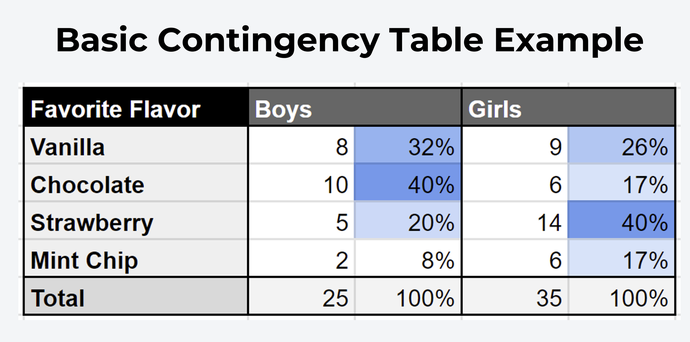 <br>

- Sometimes we'd like some order in the contingency table and this is when we will numerically code them!

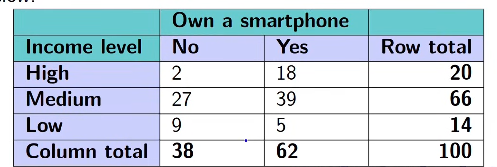 <br>
- Here we can encode the Income (High, Medium, Low) as (1,2,3)
- We'd like to maintain the order for the ordinal data.


In [159]:
# Run this cell!
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df = pd.DataFrame({
    "Gender": [
        "M","F","M","F","M",
        "F","M","F","M","F",
        "M","F","M","F","M",
        "F","M","F","M","F",
        "M","F","M","F","M"
    ],

    "Ownership": [
        "Y","Y","Y","N","Y",
        "Y","N","Y","Y","N",
        "Y","Y","Y","Y","N",
        "Y","Y","N","Y","Y",
        "Y","Y","N","Y","Y"
    ]
})
# Table representing the above dataset!
table = pd.crosstab(
    df["Gender"],
    df["Ownership"],
    margins = True
    # normalize = True
)

print(table)


Ownership  N   Y  All
Gender               
F          3   9   12
M          3  10   13
All        6  19   25


In [19]:
# Creating Percentage Table
table_percent = pd.crosstab(
    df["Gender"],
    df["Ownership"],
    margins=True,
    normalize = True
) * 100
print(table_percent.round(2))

Ownership     N     Y    All
Gender                      
F          12.0  36.0   48.0
M          12.0  40.0   52.0
All        24.0  76.0  100.0


## Row/Column Relative Frequency!

1. Row relative Frequency
- We get it by dividing each cell by it's row total
    - It answers:
    1. What proportion of total participants are female
    2. What proportion of smart phone owner are female
2. Column relative Frequency 
- We get it by dividing each cell by it's column total
    - It answers:
    1. What proportion of total participants are female?
    2. What proportion of smart phone owener are female?

___
```python
row_freq = table.sum(axis=1) : #Row Frequency Total
col_freq = table.sum(axis=0) : #Column Frequency Total
normalize = "index" : Row relative frequency
normalize = "column" : Column relative frequency
```

In [30]:
# Row relative Frequency
row_relative = pd.crosstab(
    df["Gender"],
    df["Ownership"],
    margins=True,
    normalize="index"
    
)

print(row_relative)
print()
print("We can make it percentage too")
print("---------------------------")
print((row_relative * 100).round(2))

Ownership         N         Y
Gender                       
F          0.250000  0.750000
M          0.230769  0.769231
All        0.240000  0.760000

We can make it percentage too
---------------------------
Ownership      N      Y
Gender                 
F          25.00  75.00
M          23.08  76.92
All        24.00  76.00


In [29]:
# Column Frequencies
column_relative = pd.crosstab(
    df["Gender"],
    df["Ownership"],
    normalize="columns"
)

print(column_relative)
print("---------------------------")
print((column_relative).round(2))

Ownership    N         Y
Gender                  
F          0.5  0.473684
M          0.5  0.526316
---------------------------
Ownership    N     Y
Gender              
F          0.5  0.47
M          0.5  0.53


# Association between two categorical variables

## What do we mean when two varaibles are associated?
- When we know some information about one varaible provides information about the other variable.

- Notion: <br>
- **If row relative frequency(column relative frequency) are same for all rows (columns) then we say that two variables are not associated with each other**

- **If row relative frequency(column relative frequency) are different for some rows (columns) then we say that two variables are associated with each other**

## Analyzing

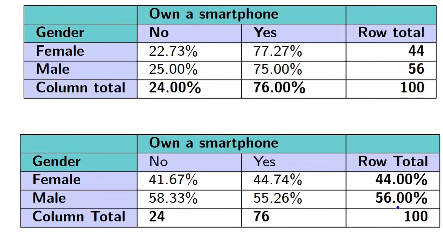 <br>

- Dataset A1
    - In each row/column it is very similar percentage = No Association
- Dataset A2
    - I have again very similar gender diversity in each column
    - All rows also have very consistent frequency
- *These two variables are not associated*
__
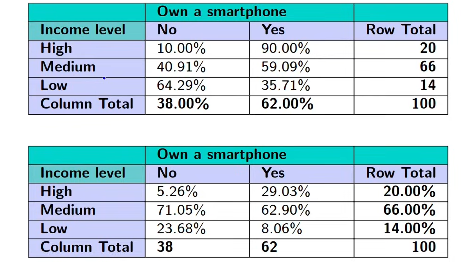 <br>
- Dataset B1
    - For each row there is inconsistency with how frequency is distributed
- Dataset B2
    - For each column (20,66,14) are not consisten with all other columns
- *Income and smartphone ownership are associated*

## Stacked Bar Chart!

- A stacked bar chart is a special type of bar chart used to display:
    - The total frequency of each category.
    - The composition of that total into smaller subgroups.
    - Each category is superiposed

### Advantage:
1. It can show total as well as parts simulataneously
2. Space Efficient
3. Best for contigency tables

### Disadvantgae:
1. No baselines
2. Too many categories is messy
3. Exact values are hard to read

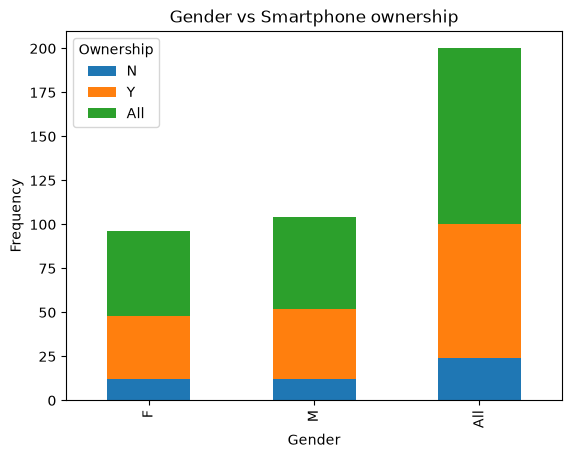

In [31]:
# We can plot it

# we can plot this
table.plot(kind="bar", stacked = True)
plt.title("Gender vs Smartphone ownership")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

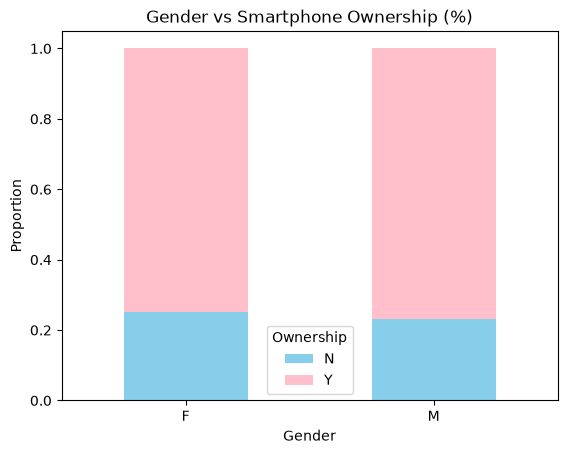

In [34]:
row_percent = pd.crosstab(
    df["Gender"],
    df["Ownership"],
    normalize="index"
)

row_percent.plot(
    kind="bar",
    stacked=True,
    color = ['skyblue', 'pink']
)

plt.title("Gender vs Smartphone Ownership (%)")
plt.ylabel("Proportion")
plt.xticks(rotation=0) # rotates the labels
plt.show()

                 A     B      C  Row Total
Bought Items  1000  1500   4000       6500
Not Bought    2000  4000  20000      26000
Column Total  3000  5500  24000      32500


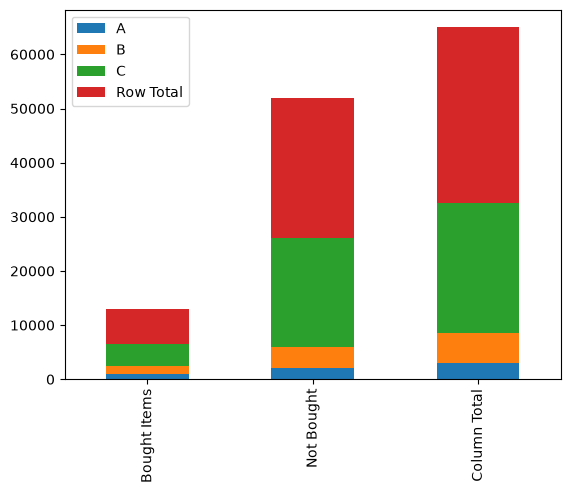

In [41]:
# Creating a contigency table to check for association

table = pd.DataFrame(
    { 
        "A" : [1000,2000],
        "B" : [1500,4000],
        "C" : [4000,20000],
    }, index = ["Bought Items", "Not Bought"]
)
table["Row Total"] = table.sum(axis = 1)
table.loc["Column Total"] = table.sum()
# Check out dataframe notes!
print(table)  

# I will plot it now!
table.plot(kind="bar", stacked=True)
plt.show()

## Question
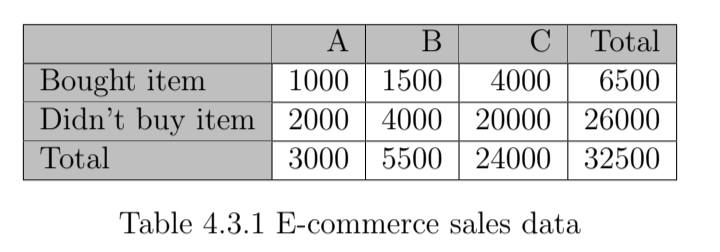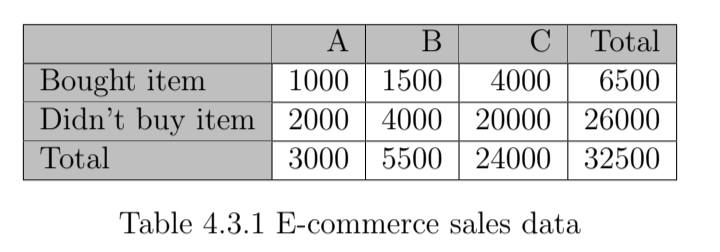 <br>

### Analysis 
- 33% of people who visited site A bought it!
- The distribution changes column by column so there is an association!

                     A         B         C
Bought Items  0.153846  0.230769  0.615385
Not Bought    0.076923  0.153846  0.769231
                  A      B      C
Bought Items  15.38  23.08  61.54
Not Bought     7.69  15.38  76.92
Column Relative Frequency
                     A         B         C
Bought Items  0.333333  0.272727  0.166667
Not Bought    0.666667  0.727273  0.833333
                  A      B      C
Bought Items  33.33  27.27  16.67
Not Bought    66.67  72.73  83.33


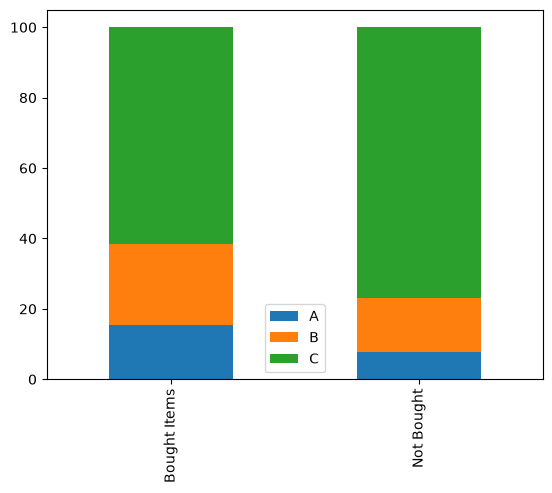

In [49]:
# Plotting relative row frequencies!
table = pd.DataFrame(
    { 
        "A" : [1000,2000],
        "B" : [1500,4000],
        "C" : [4000,20000],
    }, index = ["Bought Items", "Not Bought"]
)
row_relative = table.div(table.sum(axis=1), axis = 0)
print(row_relative)
row_relative = 100 * row_relative
print(row_relative.round(2))

row_relative.plot(kind="bar",stacked = True)

print("=============================")
print("Column Relative Frequency")
col_relative = table.div(table.sum(axis=0), axis = 1)
print(col_relative)
col_relative = 100* col_relative
print(col_relative.round(2))

# Association between two Numerical Variables!

## Scatter Plot <br>

> A scatter plot is a graph in which each observation is represented by a point whose coordinates are values of two numerical variables.'

- We want to plot this on a 2D plant
- X: Axis -> Explanatory variable
- Y: Axis -> Response variable
    - Understand we try to explain along the y axis.

## Example

- A real state agent collected prices of different size of home.
- What is the relationship between the price of a home and size?
- If prices of homes increased with the size or?
- Both of them are numberical variables

In [50]:
# Analysis!
df = pd.DataFrame({
    "Size": [0.8,1.0,1.1,1.3,1.6,1.8,2.3,2.3,2.5,2.5,2.7,3.1,3.1,3.2,3.4],
    "Price": [68,81,72,91,87,56,83,112,93,98,136,109,122,159,170]
})

print(df)

    Size  Price
0    0.8     68
1    1.0     81
2    1.1     72
3    1.3     91
4    1.6     87
5    1.8     56
6    2.3     83
7    2.3    112
8    2.5     93
9    2.5     98
10   2.7    136
11   3.1    109
12   3.1    122
13   3.2    159
14   3.4    170


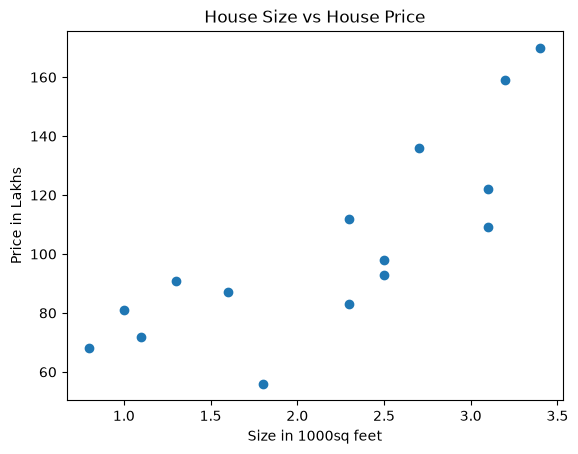

In [52]:
plt.scatter(
    df["Size"],
    df["Price"]
)
plt.title("House Size vs House Price")
plt.xlabel("Size in 1000sq feet")
plt.ylabel("Price in Lakhs")
plt.show()

## Describing Associating using Scatter Plot

- 4 key Ideas
    1. Direction: Trend go up or down?
    2. Curvature: Linear or curved?
    3. Variation: Are points tighly clustured?
    4. Outliers: Anything unexpected?

1. Direction
- Upward Direction  : Y inc with an inc in X
- Downward Direction: Y dec with an inc in X
- No obvious Direction : can't tell
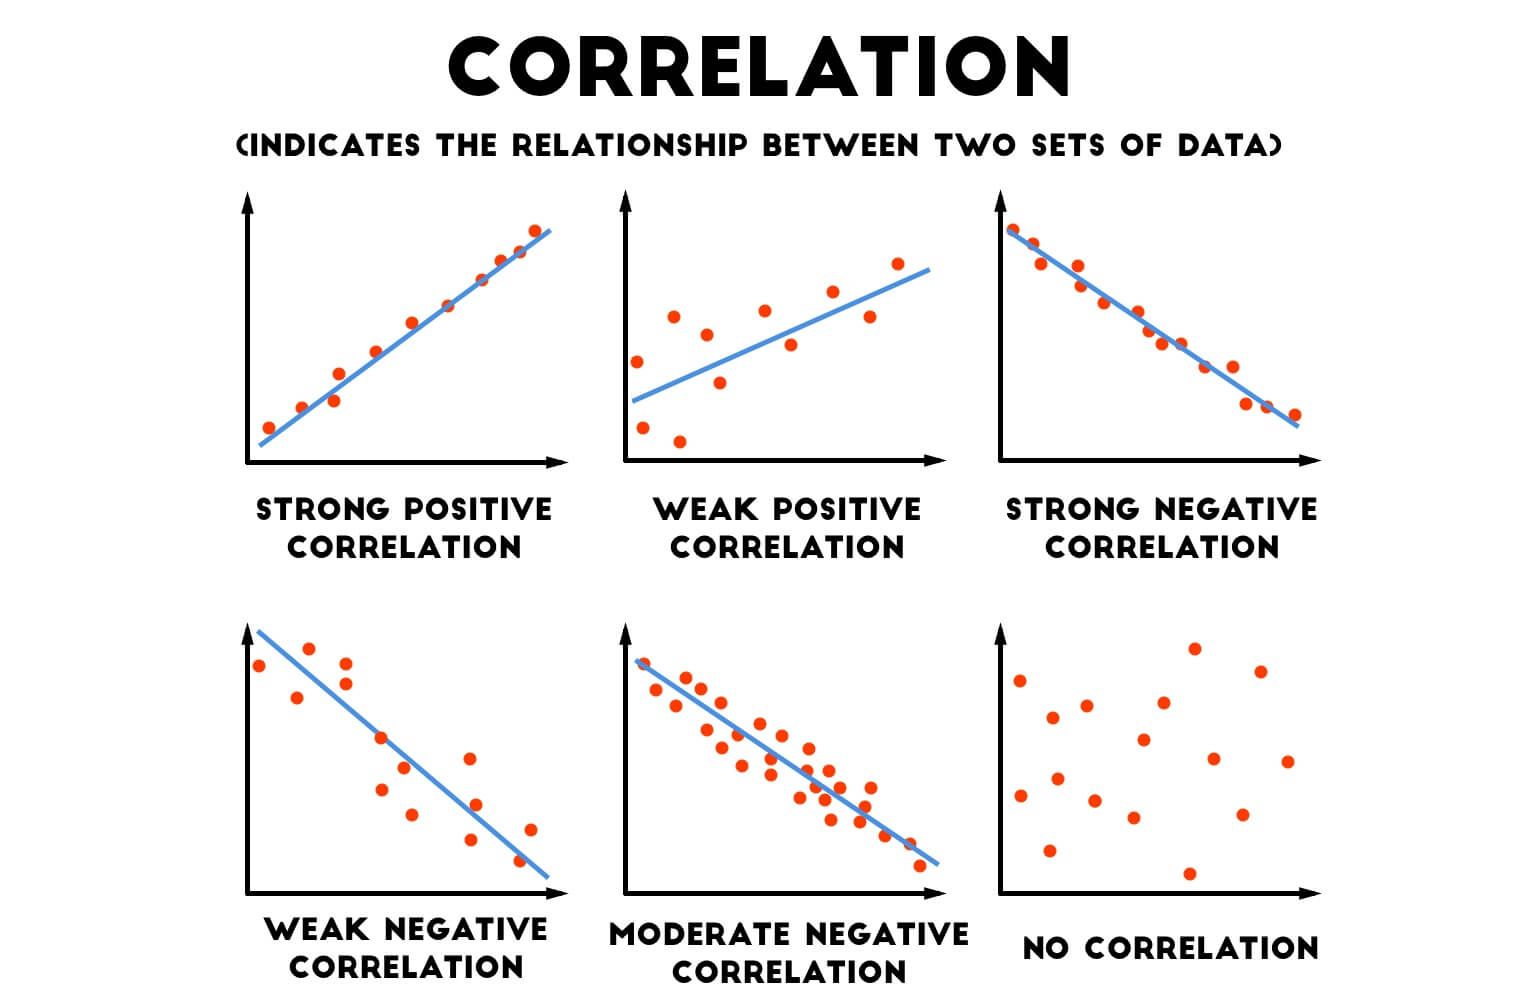 <br>

2. Curvature
- When curve fits the given data trend.
- Relationship chagnes at different rates not linear
- We will only focus on linear for this course
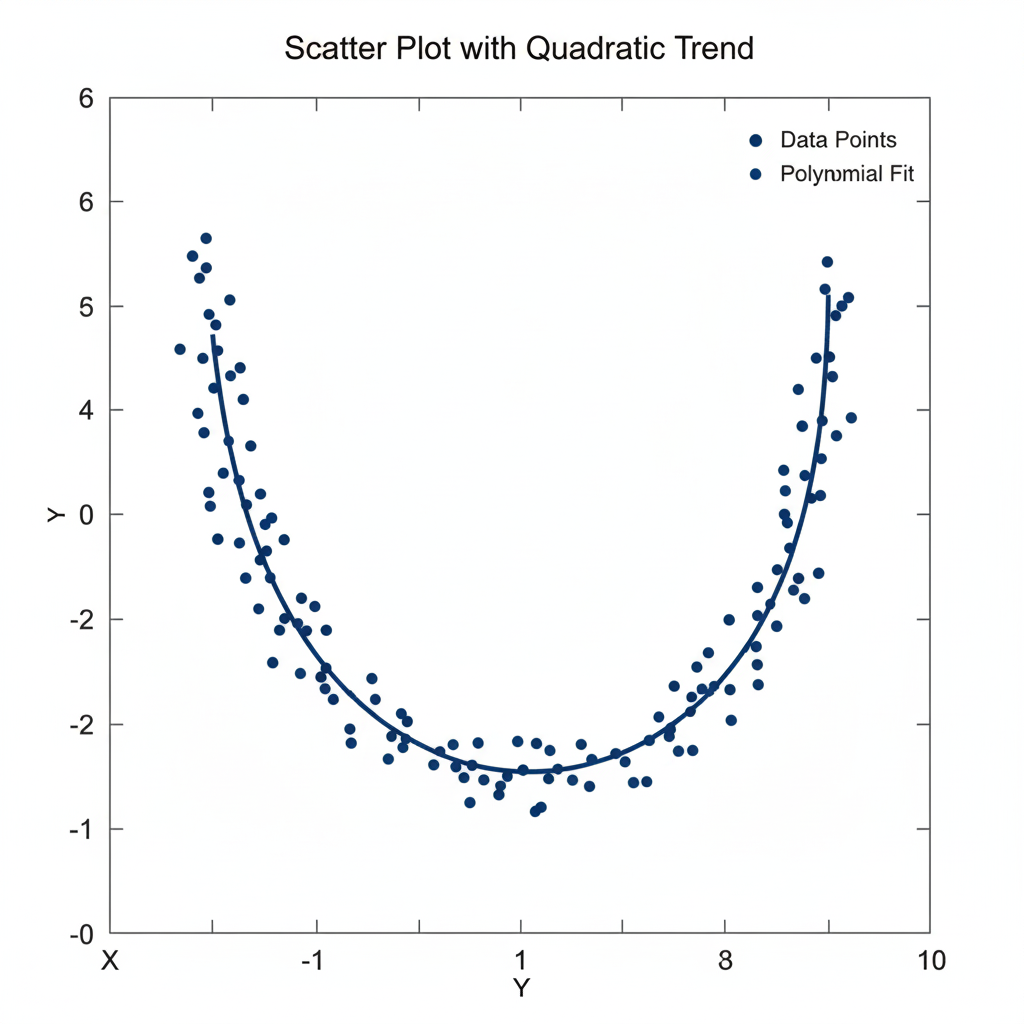 <br>

3. Variation
- Variation refers to how closely the points cluster around the overall pattern.
    - Weak Association: Points are widely scattered
    - Strong Association: Points are properly tightly scattered
    - No Association: No recognizable pattern
    - In the image under direction we see strongly and weakly related which is nothing but variation
4. Outliers
- They lie outside of the trend if it exist

# Measures of Association
> Quantify the strength of the associations (Measure of linear correlations)

- We need something better as scatter plot does not provide a precise numerical measure.
1. Covariance
2. Correlation

## Covariance

- Covariance measures how two variables vary together.
- It tells us whether:
    - Large values of one variable occur with large values of another variable.
    - Large values of one variable occur with small values of another variable.

---
- When we plot the scatter plots and find the mean of x and y axis
- It divides our Graph in 4 quadrants
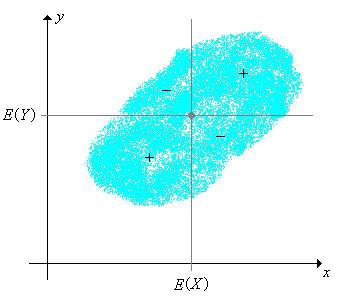 <br>
- We Wanna calculate the deviations from x and y and multiply them
$$
(x_i-\bar{x})(y_i-\bar{y})
$$
- We can think of this as
    - Positive × Positive = Positive
    - Negative × Negative = Positive
    - Positive × Negative = Negative

#### Observations
- If Large values(small) values of x tend to be associated with large(small) values of y- the signs of deviations in x and y tend to be the **same**
- If Large values(small) values of x tend to be associated with small(large) values of y- the signs of deviations in x and y tend to be the **different**

#### Define: Population Covariance
$$
\operatorname{Cov}(X,Y)
=
\frac{
\sum_{i=1}^{N}
(x_i-\mu_X)
(y_i-\mu_Y)
}
{N}
$$

#### Define: Sample Covariance
$$
s_{XY}
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})
(y_i-\bar{y})
}
{n-1}
$$

---

- Let's Talk about the types
### Positive Covariance: Cov(X,Y) > 0

> When two variables have positive covariance, they move in the same direction. This means if one variable increases, the other variable also increases, and vice versa.

### Negative Covariance: Cov(X,Y) < 0

> When two variables have negative covariance, they move in opposite directions. This means if one variable increases, the other tends to decrease, and vice versa.


### No Covariance: Cov(X,Y) ~ 0

>A covariance close to zero means the variables are not linearly related.

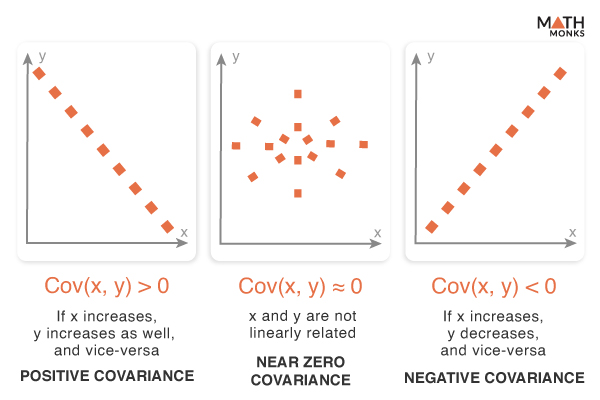 <br>

## Disadvantage
```
Dataset A : Covariance = 10
Dataset B : Covariance = 10000

Can we conclude B has a stronger relationship?

No, As Covariance depends on units.
Changing units changes covariance.
We need Something Better!
```

## We will practice with these two datasets
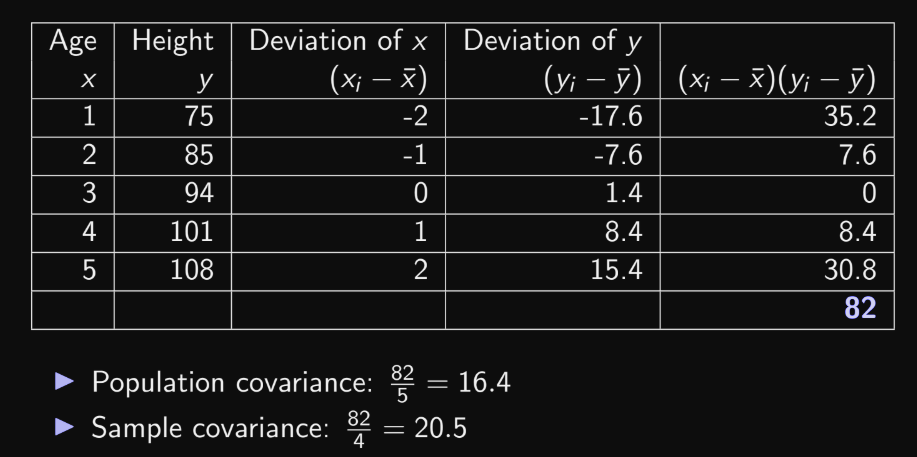 <br>
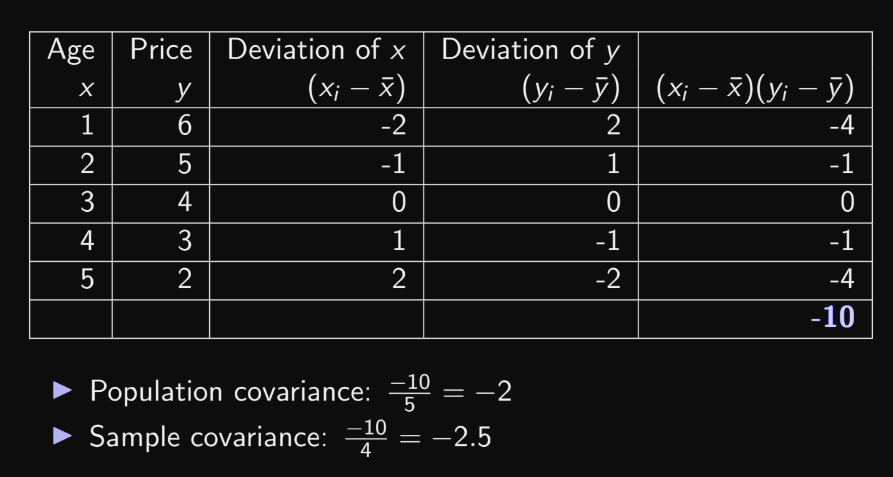 <br>

In [58]:

df_1 = pd.DataFrame({
    "Age": [1, 2, 3, 4, 5],
    "Height": [75, 85, 94, 101, 108]
})
df_2 = pd.DataFrame({
    "Age": [1, 2, 3, 4, 5],
    "Price": [6, 5, 4, 3, 2]
})

print(df_1)
print(df_1.info())
print(df_1.describe())
print("==================================")
print(df_2)
print(df_2.info())
print(df_2.describe())

   Age  Height
0    1      75
1    2      85
2    3      94
3    4     101
4    5     108
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     5 non-null      int64
 1   Height  5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None
            Age      Height
count  5.000000    5.000000
mean   3.000000   92.600000
std    1.581139   13.011533
min    1.000000   75.000000
25%    2.000000   85.000000
50%    3.000000   94.000000
75%    4.000000  101.000000
max    5.000000  108.000000
   Age  Price
0    1      6
1    2      5
2    3      4
3    4      3
4    5      2
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     5 non-null      int64
 1   Price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None
            Age     

In [68]:
# Calculating the Covariance (Sample Covariance by default)
cov_positive = df_1["Age"].cov(df_1["Height"])
cov_negative = df_2["Age"].cov(df_2["Price"])

print(cov_positive)
print(cov_negative)

20.5
-2.5


In [109]:
# Calculating Covariance Population

def population_cov(dataset, x, y):
    n = len(dataset)
    
    population_cov_result = (
        ((dataset[x] - dataset[x].mean()) *
         (dataset[y] - dataset[y].mean()))
        .sum() / n
    )
    return population_cov_result
a = population_cov(df_1, "Age", "Height")
b = population_cov(df_2, "Age", "Price")
print(a)
print(b)


16.4
-2.0


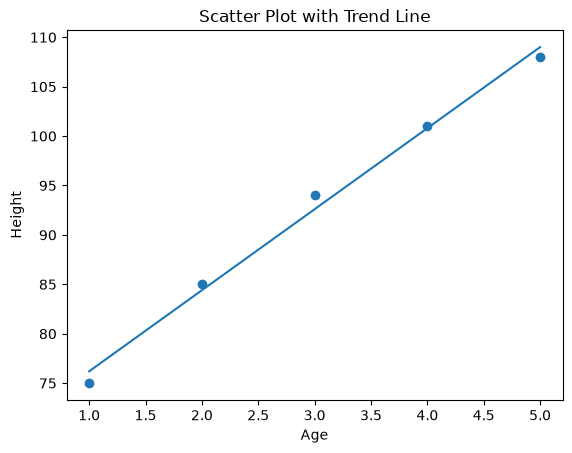

In [97]:
# Plotting the first one!

import numpy as np

x = df_1["Age"]
y = df_1["Height"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)

plt.plot(
    x,
    m*x + b
)

plt.xlabel("Age")
plt.ylabel("Height")
plt.title("Scatter Plot with Trend Line")

plt.show()

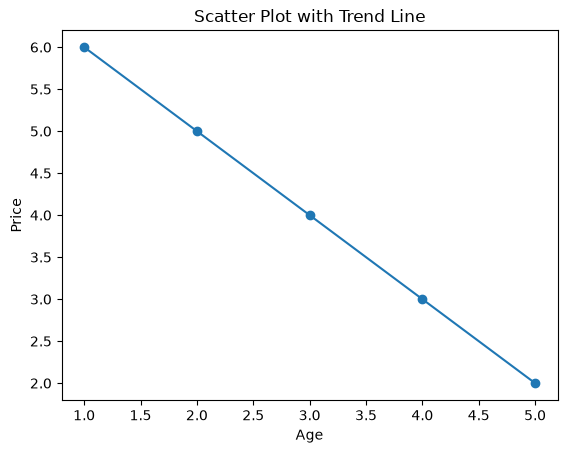

In [100]:
# For the second one!
x = df_2["Age"]
y = df_2["Price"]

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)

plt.plot(
    x,
    m*x + b
)

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Scatter Plot with Trend Line")

plt.show()

In [107]:
# Summary For Covariance!
df1 = pd.DataFrame({
    "Age": [1, 2, 3, 4, 5],
    "Height": [75, 85, 94, 101, 108]
})

# Dataset 2
df2 = pd.DataFrame({
    "Age": [1, 2, 3, 4, 5],
    "Price": [6, 5, 4, 3, 2]
})
# Sample covariance
df1["Age"].cov(df1["Height"])
df2["Age"].cov(df2["Price"])

# Covariance matrix
df1.cov()
df2.cov()

# ==============================
# NUMPY
# ==============================

# Sample covariance matrix
np.cov(df1["Age"], df1["Height"])
np.cov(df2["Age"], df2["Price"])

# Sample covariance only
np.cov(df1["Age"], df1["Height"])[0, 1]
np.cov(df2["Age"], df2["Price"])[0, 1]

# Population covariance matrix
np.cov(df1["Age"], df1["Height"], bias=True)
np.cov(df2["Age"], df2["Price"], bias=True)

# Population covariance only
np.cov(df1["Age"], df1["Height"], bias=True)[0, 1]
np.cov(df2["Age"], df2["Price"], bias=True)[0, 1]

np.float64(-2.0)

## Corelation

> We will now standardize it as it is unitless!

- It measures strength and direction for bi-variate analysis
- We talk about *Pearson Correlation Coefficient* (r)

$$
r
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})
(y_i-\bar{y})
}
{
\sqrt{
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}
\sqrt{
\sum_{i=1}^{n}
(y_i-\bar{y})^2
}
}
$$

- which is same as

$$
r
=
\frac{
\operatorname{Cov}(X,Y)
}
{
s_X s_Y
}
$$

- Here Sx and Sy are they standard deviations of x and y
- Correlation has no units- You can check dimensional Analysis
- *It always lies between [-1,1]
$$
-1 \le r \le 1

### Interpretation
1. Perfect Positive Correlation  : r = 1
2. Perfect Negative Correlation  : r = -1
3. Strong Positive Correlation   : 0.7 <= r < 1
4. Moderate Positive Correlation : 0.3 <= r < 0.7
5. Weak Positive Correlation     : 0 < r < 0.3
6. No Correlation                : r ~ 0
7. Weak Negative Correlation     : -0.7 < r <= -0.3
8. Strong Negarive Correlation   : -1 < r <= -0.7

### Properties
1. It is unitless
2. It has a boundary
3. It is symmetric r(X,Y) = r(Y,X)
4. Measures Linear Association


- Summary
    - Covariance tells us whether two variables move together. Correlation tells us both how they move together and how strongly they are related.

## Equation of Best fitting Line and R^2

### Line of best fit

- A **line of best fit** is the straight line that best represents the relationship between two quantitative variables.
    - It captures the overall trend
    - As close as possible to all points
    - Minimize prediction errors
- Y = mX + c
### (R^2)
- R^2 can be in between [0,1] and it gives us the goodness of fit measure
- R ~ 0 : We can't have a best fitting line
- R ~ 1 : We can explain it with the best fitting line

In [112]:
# Finding the best fit line using numpy

def bestfitline(dataset,x,y):
    slope, intercept = np.polyfit(
        dataset[x],
        dataset[y],
        deg=1
    )
    print("Slope:", slope)
    print("Intercept:", intercept)
    print(f"Equation: y = {slope:.4f}x + {intercept:.4f}")

bestfitline(df_1,"Age", "Height")


Slope: 8.200000000000003
Intercept: 67.99999999999999
Equation: y = 8.2000x + 68.0000


In [114]:
# Summary!

x = df_1["Age"]
y = df_1["Height"]

# Correlation
r_pandas = x.corr(y)
r_numpy = np.corrcoef(x, y)[0,1]

# R²
r_squared = r_pandas**2

print("="*40)

print("PANDAS CORRELATION")
print(r_pandas)

print("\nNUMPY CORRELATION")
print(r_numpy)

print("\nR²")
print(r_squared)
print("="*40)

PANDAS CORRELATION
0.9964496929345307

NUMPY CORRELATION
0.9964496929345307

R²
0.9929119905493204


# Association between numerical and categorical value

## Point Bi-Serial Correlation

> Point-biserial correlation is a special case of Pearson correlation and examines the relationship between a dichotomous categorical+ variable and a numerical variable.

- Measures the association between:

- One **binary categorical variable** (e.g., Gender, Pass/Fail)
- One **numerical variable** (e.g., Marks, Salary)


- We will numerically encode the categorical variable and then it is very similar to Pearson Coeffcient of correlation!

### Define
$$
r_{pb}
=
\frac{\bar y_1-\bar y_0}
{s_y}
\sqrt{pq}
$$
where <br>
$\bar y_1$ = mean of group 1 <br>
$\bar y_0$ = mean of group 0 <br>
$s_y$      = standard deviation of all scores <br>
p          = proportion in group 1 <br>
q          = proportion of group 0 = 1 - p <br>

- It lies between 0 to 1 as well

___
### Range

$$
-1 \le r_{pb} \le 1
$$

| Value | Interpretation |
|---------|---------|
| +1 | Perfect Positive Association |
| 0 | No Association |
| -1 | Perfect Negative Association |

---

### Strength Guidelines

| $|r_{pb}|$ | Strength |
|-----------|----------|
| 0.00 - 0.19 | Very Weak |
| 0.20 - 0.39 | Weak |
| 0.40 - 0.59 | Moderate |
| 0.60 - 0.79 | Strong |
| 0.80 - 1.00 | Very Strong |

- Sign (+/-) indicates which group has the higher mean.
---
### Example
1. $r_{pb}$ = 0.72
- There is a strong positive association between Gender and Marks. The group coded as 1 tends to obtain higher marks.

2. $r_{pb}$ = -0.51
- There is a moderate negative association between Gender and Marks. The group coded as 0 tends to obtain higher marks.

3. $r_{pb}$ = 0.04
- There is essentially no association between Gender and Marks.
  


In [115]:
df_3 = pd.DataFrame({
    "Gender":["F","F","F","M","M","M","F","F","F","F",
              "M","F","M","M","F","F","F","M","F","M"],
    "Marks":[71,67,65,69,75,83,91,85,69,75,
             92,79,71,94,86,75,90,84,91,90]
})

# We wanna know if Marks are related to Gender!
print(df_3)

   Gender  Marks
0       F     71
1       F     67
2       F     65
3       M     69
4       M     75
5       M     83
6       F     91
7       F     85
8       F     69
9       F     75
10      M     92
11      F     79
12      M     71
13      M     94
14      F     86
15      F     75
16      F     90
17      M     84
18      F     91
19      M     90


In [130]:
# Encoding the Gender through mapping
df_3["Gender_Code"] = df_3["Gender"].map({
    "F":0,
    "M":1
})

# We can directly calculate the Pearson Correlation
r_pb = df_3["Gender_Code"].corr(df_3["Marks"])
print(r_pb)

0.18810861468976817


In [137]:
#numpy
# gender = np.where(
#     df["Gender"]=="M",
#     1,
#     0
# )

r_pb = np.corrcoef(
    df_3["Gender_Code"],
    df_3["Marks"]
)[0,1]

print(r_pb)

0.18810861468976817


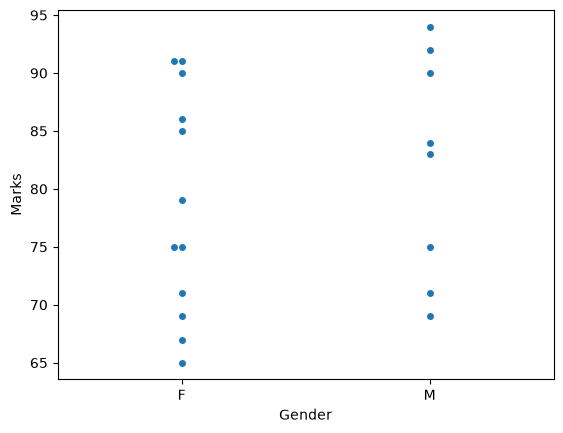

In [140]:
sns.swarmplot(
    data=df_3,
    x="Gender",
    y="Marks"
)

plt.show()

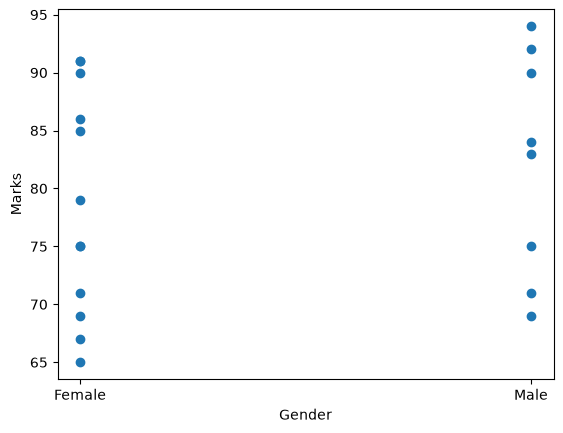

In [144]:
plt.scatter(
    df_3["Gender_Code"],
    df_3["Marks"]
)
plt.xticks( [0,1], ["Female", "Male"])
plt.xlabel("Gender")
plt.ylabel("Marks")
plt.show()


### Observation! 
- This dataset has no correlation between the variables!
- If they are distributed at some different y level we could have seen the relation.
- Box Plot is the best graph for visualizing it as well

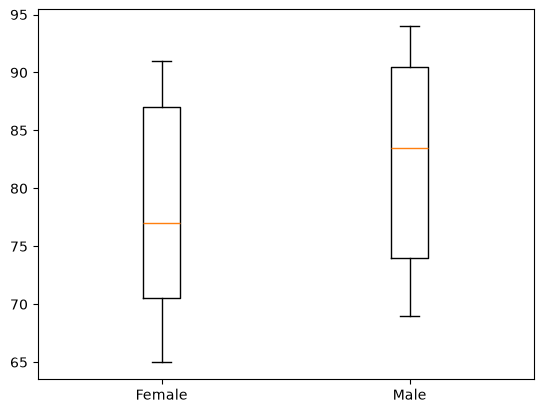

In [157]:

female_marks = df_3[df_3["Gender"] == "F"]["Marks"]
male_marks = df_3[df_3["Gender"] == "M"]["Marks"]

plt.boxplot(
    [female_marks, male_marks],
    tick_labels=["Female", "Male"]
)

plt.show()


Text(0, 0.5, 'Marks')

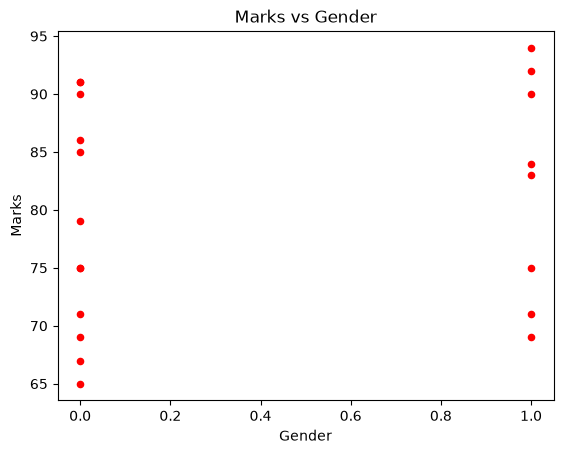

In [156]:
# Pandas Scatter btw which is much easier

ax = df_3.plot.scatter(
    x="Gender_Code",
    y="Marks",
    c = 'red',
    title="Marks vs Gender"
)
ax.set_xlabel("Gender")
ax.set_ylabel("Marks")